# Interpreting ESMC Features in Structural Proteins (Sparse Autoencoders)

### Markus J. Buehler, MIT

Focus: silk & other structural/biomaterials proteins.

A protein language model packs a lot into each residue's embedding, but those 2560 dimensions are
**polysemantic** (each mixes many concepts). A **Sparse Autoencoder (SAE)** re-expresses every
residue embedding as a sparse combination of **16,384 interpretable features**, of which only the
**top k = 64** are active per residue. Many features turn out to be (approximately) *monosemantic* —
they fire for one recognizable concept: a structural motif, a compositional bias, a binding site, a
fold/family signal…

We use the **ESMC-6B SAE trained on layer 60** (`biohub/ESMC-6B-sae-...`) and ask, specifically for
**structural proteins**:

1. **Motif-localized features** — which features fire sharply on silk's `poly-Ala` crystals, `GPGXX`
   turns, collagen `GXY`, elastin `VPGVG`?
2. **Order vs. disorder / domain features** — which broad features separate crystalline from
   amorphous/disordered regions, or mark whole domains?
3. **Map features onto 3-D** — project activations onto an **ESMFold2**-predicted structure (local).
4. **Compare across families** — feature *fingerprints*: what is shared vs. unique across
   silk / collagen / elastin / keratin / globular, and how do proteins cluster by features?

> The official tutorial calls the Biohub **Forge API** (`ESMCForgeInferenceClient`, needs a token).
> Here we use the **local Hugging Face path**: load ESMC-6B + the SAE weights and run on this machine.
> Feature *descriptions* are fetched from a **keyless** public endpoint (`biohub.ai/.../features/<id>`).

## 0 · Setup

Uses the dedicated **`esm`** environment (same as the companion notebook). ESMC-6B is large
(~25 GB) and the model is written for CUDA; with no GPU we run it on **CPU in float32** — fine here
(plenty of RAM), just not instant. A forward pass for a ~150-residue protein takes a few seconds.

In [1]:
import os, json, urllib.request, urllib.parse, time
os.environ.setdefault("PYTORCH_ENABLE_MPS_FALLBACK", "1")
os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")
import numpy as np, torch, matplotlib.pyplot as plt
from pathlib import Path

# ESMC-6B + diffusion-free SAE run on CPU (fp32). MPS lacks some ops for the 6B/SAE path.
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", DEVICE, "| torch", torch.__version__)

RESULTS = Path("results_sae"); RESULTS.mkdir(exist_ok=True)
def savefig(fig, name):
    for ext in ("png", "svg"):
        fig.savefig(RESULTS / f"{name}.{ext}", dpi=150, bbox_inches="tight")
    print("saved:", RESULTS / f"{name}.png")

device: cpu | torch 2.12.0


## 1 · Load ESMC-6B and the layer-60 SAE (local)

The SAE was trained to reconstruct ESMC-6B's **layer-60** hidden states. We download just that one
layer's weights (`layer_60.safetensors`, ~few hundred MB) from the multi-layer SAE repo, attach it to
the model, and from then on every forward pass also returns sparse feature activations.

In [2]:
from transformers import AutoModel, AutoTokenizer

ESMC = "biohub/ESMC-6B"
SAE_REPO = "biohub/ESMC-6B-sae-k64-codebook16384"   # multi-layer; we grab layer 60 only
SAE_LAYER = 60

tokenizer = AutoTokenizer.from_pretrained(ESMC)
model = AutoModel.from_pretrained(ESMC).to(DEVICE).float().eval()

sae = AutoModel.from_pretrained(
    SAE_REPO,
    allow_patterns=["config.json", f"layer_{SAE_LAYER}.safetensors"],
    device=DEVICE,
)
sae.initialize_layers([SAE_LAYER])
model.add_sae_models([sae.layers[str(SAE_LAYER)]])

CODEBOOK = sae.layers[str(SAE_LAYER)].config.codebook_dim if hasattr(
    sae.layers[str(SAE_LAYER)], "config") else 16384
print(f"ESMC-6B + SAE layer {SAE_LAYER} ready on {DEVICE}: "
      f"{CODEBOOK} features, top-k=64 active per residue")

ESMC: transformer_engine is not installed; falling back to pure-PyTorch LayerNorm+Linear / LayerNorm+MLP. Outputs will differ numerically — measured on the unnormalized residual stream (before the final LayerNorm), ~O(10) max-diff in fp32 and ~O(100) in bf16; after the final LayerNorm these shrink to a few ULP and perplexity stays within rounding noise. Install with `pip install transformer-engine[pytorch]` to enable fused fp32-reduction LayerNorm.
ESMC: neither xformers nor flash-attn is installed; falling back to PyTorch ``F.scaled_dot_product_attention``. The attention reduction order in bf16 differs from a fused kernel by ~1 bf16 ULP per attention block; compounded across the 80-block stack this reaches ~O(100) max-diff on the unnormalized residual stream. Install xformers (preferred) with `pip install xformers` for a fused attention kernel.


🚨 No checkpoint found for ESMCForSequenceClassification.forward. Please add a `checkpoint` arg to `auto_docstring` or add one in ESMCConfig's docstring
🚨 No checkpoint found for ESMCForTokenClassification.forward. Please add a `checkpoint` arg to `auto_docstring` or add one in ESMCConfig's docstring


Loading checkpoint shards:   0%|          | 0/6 [00:00<?, ?it/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

ESMC-6B + SAE layer 60 ready on cpu: 16384 features, top-k=64 active per residue


## 2 · A structural-protein panel

Consensus repeat constructs make each material's motif explicit; we add real (sliced) sequences and
globular controls. We keep lengths modest so the 6B forward passes stay quick.

In [3]:
def fetch_uniprot(acc, maxlen=180):
    url = f"https://rest.uniprot.org/uniprotkb/{acc}.fasta"
    req = urllib.request.Request(url, headers={"User-Agent": "esm-class-notebook"})
    full = "".join(urllib.request.urlopen(req, timeout=30).read().decode().splitlines()[1:])
    mid = len(full) // 2
    return full[max(0, mid - maxlen // 2): mid + maxlen // 2]

PROTEINS = {
    # consensus repeats (motif grammar is explicit)
    "MaSp1 (silk consensus)":  "GGAGQGGYGGLGSQGAGRGGLGGQGAGAAAAAAAA" * 2,
    "MaSp2 (silk consensus)":  "GPGGYGPGQQGPGGYGPGQQGPSGPGSAAAAAAAA" * 2,
    "Fibroin (GAGAGS)":        "GAGAGS" * 16,
    "Collagen (GPP)":          "GPP" * 30,
    "Elastin (VPGVG)":         "VPGVG" * 18,
    "Resilin":                 "GGRPSDSYGAPGGGN" * 6,
    # globular controls
    "Ubiquitin": "MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSDYNIQKESTLHLVLRLRGG",
}
# add a couple of real ones (fetched, sliced)
for acc, name in {"P05790": "Fibroin H (real)", "P02144": "Myoglobin (real)"}.items():
    try: PROTEINS[name] = fetch_uniprot(acc)
    except Exception as e: print("fetch failed", name, e)

for n, s in PROTEINS.items():
    print(f"{n:26} {len(s):3d} aa")

MaSp1 (silk consensus)      70 aa
MaSp2 (silk consensus)      70 aa
Fibroin (GAGAGS)            96 aa
Collagen (GPP)              90 aa
Elastin (VPGVG)             90 aa
Resilin                     90 aa
Ubiquitin                   76 aa
Fibroin H (real)           180 aa
Myoglobin (real)           154 aa


## 3 · Extract SAE features

Each forward pass returns `sae_outputs["layer60"]`, a sparse `(L+2, 16384)` tensor (the +2 are the
BOS/EOS tokens, which we drop). Each residue keeps only its **top-64** features, so the matrix is
~99.6% zeros.

In [4]:
@torch.inference_mode()
def sae_features(seq):
    """Return dense SAE feature matrix (L, 16384) for one sequence."""
    inputs = {k: v.to(DEVICE) for k, v in tokenizer(seq, return_tensors="pt").items()}
    out = model(**inputs)
    feats = out["sae_outputs"][f"layer{SAE_LAYER}"].to_dense().float().cpu().numpy()
    return feats[1:-1]                                   # drop BOS/EOS -> (L, 16384)

FEATS = {}
for name, seq in PROTEINS.items():
    t0 = time.time(); F = sae_features(seq); FEATS[name] = F
    print(f"{name:26} {F.shape}  active/res={ (F>0).sum(1).mean():.0f}  "
          f"sparsity={100*(F==0).mean():.1f}%  ({time.time()-t0:.1f}s)")

MaSp1 (silk consensus)     (70, 16384)  active/res=64  sparsity=99.6%  (3.2s)
MaSp2 (silk consensus)     (70, 16384)  active/res=64  sparsity=99.6%  (0.8s)
Fibroin (GAGAGS)           (96, 16384)  active/res=64  sparsity=99.6%  (1.0s)
Collagen (GPP)             (90, 16384)  active/res=64  sparsity=99.6%  (0.8s)
Elastin (VPGVG)            (90, 16384)  active/res=64  sparsity=99.6%  (0.8s)
Resilin                    (90, 16384)  active/res=64  sparsity=99.6%  (0.8s)
Ubiquitin                  (76, 16384)  active/res=64  sparsity=99.6%  (0.8s)
Fibroin H (real)           (180, 16384)  active/res=64  sparsity=99.6%  (1.3s)
Myoglobin (real)           (154, 16384)  active/res=64  sparsity=99.6%  (1.2s)


## 4 · Feature descriptions (keyless)

Each of the 16,384 features has an **automatically generated** description (label / summary /
category) produced by an agent that examined where the feature fires across millions of proteins.
We fetch these from a public endpoint. *Treat them as hypotheses, not ground truth.*

In [5]:
from functools import lru_cache

@lru_cache(maxsize=8192)
def feature_info(idx):
    """Description metadata for an SAE feature (keyless public endpoint)."""
    url = f"https://biohub.ai/esm/protein/api/v1alpha1/features/{int(idx)}"
    try:
        req = urllib.request.Request(url, headers={"User-Agent": "esm-class-notebook"})
        return json.load(urllib.request.urlopen(req, timeout=20))
    except Exception as e:
        return {"label": "(unavailable)", "category": None, "summary": str(e)[:60]}

def label_of(idx):
    d = feature_info(idx); return f"{d.get('label','?')}  [{d.get('category')}]"

# sanity check
for idx in list(FEATS.values())[0].max(0).argsort()[::-1][:3]:
    print(f"feature {idx:5d}: {label_of(int(idx))}")

feature  9005: Unknown generic feature  [None]
feature  1803: Unknown generic feature  [None]
feature 14534: Unknown generic feature  [None]


## 5 · Analysis A — motif-localized features

Features that fire as **sharp peaks** tend to mark short, specific motifs. For a spider-silk protein
we find the most strongly activating features and plot them along the sequence; the peaks should line
up with the **poly-alanine crystalline blocks** and the **glycine-rich** repeats.

Top features by max activation in MaSp2 (silk consensus) -> [9005, 1803, 14534, 14895]
saved: results_sae/A_motif_features_masp2.png


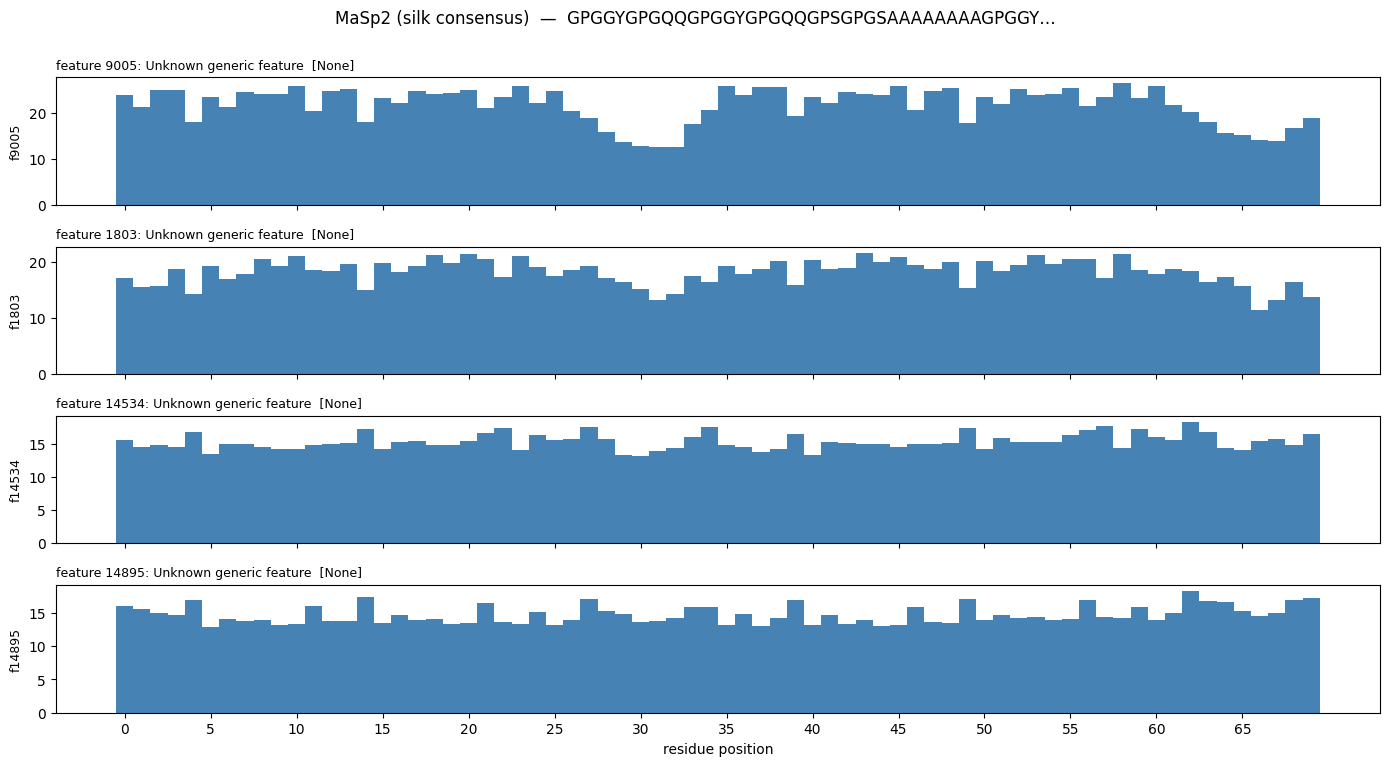

In [6]:
def plot_features_on_sequence(name, feature_ids, fname=None):
    seq = PROTEINS[name]; F = FEATS[name]
    fig, axes = plt.subplots(len(feature_ids), 1, figsize=(14, 1.9 * len(feature_ids)), sharex=True)
    axes = np.atleast_1d(axes)
    for ax, fid in zip(axes, feature_ids):
        ax.bar(np.arange(len(seq)), F[:, fid], width=1.0, color="steelblue")
        ax.set_ylabel(f"f{fid}", fontsize=9)
        ax.set_title(f"feature {fid}: {label_of(int(fid))}", fontsize=9, loc="left")
    axes[-1].set_xlabel("residue position")
    # annotate the sequence motif track on the bottom axis
    axes[-1].set_xticks(range(0, len(seq), 5))
    fig.suptitle(f"{name}  —  {seq[:40]}…", y=1.002)
    plt.tight_layout()
    if fname: savefig(fig, fname)
    plt.show()

silk = "MaSp2 (silk consensus)"
top_local = FEATS[silk].max(0).argsort()[::-1][:4]
print("Top features by max activation in", silk, "->", top_local.tolist())
plot_features_on_sequence(silk, top_local, fname="A_motif_features_masp2")

Compare the peak positions with the sequence: in `…GPGGYGPGQQ…AAAAAAAA`, do some features
fire specifically on the **poly-Ala** stretch and others on the **GPGXX** turns? Re-run with
`silk = "Fibroin (GAGAGS)"` or `"Collagen (GPP)"` to see motif-specific features for other materials.

## 6 · Analysis B — order/disorder & domain-level features

Features that are **prevalent** (active across many residues) tend to capture *broad* properties:
low-complexity/disorder, repeat character, or whole-domain/fold signals. We rank features by
prevalence (vs. max activation), and contrast a **disordered, repetitive silk** with a **folded
globular** protein.

In [7]:
def top_features(name, by="prevalence", k=8, thresh=0.0):
    F = FEATS[name]
    score = (F > thresh).sum(0) if by == "prevalence" else F.max(0)
    ids = np.argsort(score)[::-1][:k]
    return [(int(i), float(score[i])) for i in ids]

for name in [silk, "Ubiquitin"]:
    print(f"\n### {name} — most PREVALENT features (broad signals)")
    for fid, sc in top_features(name, by="prevalence", k=5):
        print(f"  f{fid:5d} active@{int(sc):3d}/{len(PROTEINS[name])} res | {label_of(fid)}")


### MaSp2 (silk consensus) — most PREVALENT features (broad signals)
  f11429 active@ 70/70 res | Gly/Ser-rich disordered low-complexity regions  [Compositional bias]
  f15662 active@ 70/70 res | Secreted low-complexity adhesive repeats  [Compositional bias]
  f 1803 active@ 70/70 res | Unknown generic feature  [None]
  f 9005 active@ 70/70 res | Unknown generic feature  [None]
  f14895 active@ 70/70 res | Unknown generic feature  [None]

### Ubiquitin — most PREVALENT features (broad signals)
  f 9005 active@ 76/76 res | Unknown generic feature  [None]
  f14895 active@ 76/76 res | Unknown generic feature  [None]
  f 9194 active@ 76/76 res | Unknown feature  [None]
  f 1803 active@ 76/76 res | Unknown generic feature  [None]
  f 3995 active@ 75/76 res | Ubiquitin-like domain modules  [Domain]


saved: results_sae/B_disorder_score.png


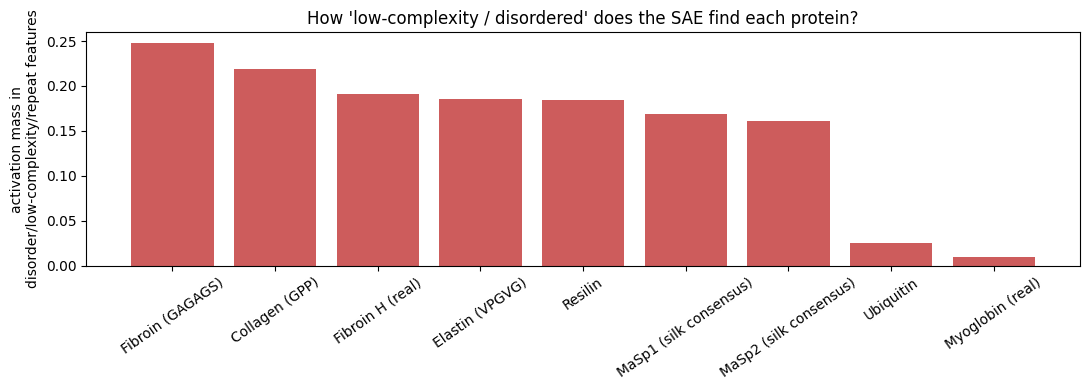

In [8]:
# A "disorder/repeat-ness" score per protein: fraction of residues where any of the protein's
# top prevalence features is a known low-complexity/disorder/repeat feature.
def category_fraction(name, keywords=("disorder", "low-complexity", "repeat", "compositional")):
    F = FEATS[name]
    ids = np.argsort((F > 0).sum(0))[::-1][:20]          # 20 most prevalent features
    hits = [i for i in ids if any(k in (str(feature_info(int(i)).get("label","")).lower()
            + str(feature_info(int(i)).get("category","")).lower()) for k in keywords)]
    # mean activation mass carried by those features
    return float(F[:, hits].sum() / (F.sum() + 1e-9)) if hits else 0.0

names = list(PROTEINS)
frac = [category_fraction(n) for n in names]
order = np.argsort(frac)[::-1]
fig, ax = plt.subplots(figsize=(11, 4))
ax.bar([names[i] for i in order], [frac[i] for i in order], color="indianred")
ax.set_ylabel("activation mass in\ndisorder/low-complexity/repeat features")
ax.set_title("How 'low-complexity / disordered' does the SAE find each protein?")
ax.tick_params(axis="x", rotation=35)
plt.tight_layout(); savefig(fig, "B_disorder_score"); plt.show()

Silks, elastin, and resilin should score high (they *are* low-complexity / disordered until
assembled), while ubiquitin/myoglobin (folded globular) should score low — the SAE recovers a
biologically meaningful order/disorder axis. *Discuss: where does collagen fall, and why?*

## 7 · Analysis C — map a feature onto a 3-D structure (ESMFold2, local)

The tutorial colored a crystal structure from the PDB. Silk has no good folded PDB entry (it's
disordered), so we **predict** a structure locally with ESMFold2 and paint each residue by a chosen
SAE feature's activation. *(Loads ESMFold2's own 6B backbone — a second large model; guarded.)*

In [9]:
MAP_3D = True   # set False to skip (loads ESMFold2 ~ another large model)

if MAP_3D:
    from contextlib import nullcontext
    from transformers.models.esmfold2.modeling_esmfold2 import ESMFold2Model
    from esm.models.esmfold2 import ESMFold2InputBuilder, ProteinInput, StructurePredictionInput

    map_name = "MaSp1 (silk consensus)"           # which protein to fold + paint
    map_seq = PROTEINS[map_name]
    feat_to_map = int(FEATS[map_name].max(0).argmax())   # its single strongest feature

    fold = ESMFold2Model.from_pretrained("biohub/ESMFold2-Fast")
    fold = (fold.float() if DEVICE != "cuda" else fold).to(DEVICE).eval()
    spi = StructurePredictionInput(sequences=[ProteinInput(id="A", sequence=map_seq)])
    amp = (torch.autocast(device_type="cuda", dtype=torch.bfloat16)
           if DEVICE == "cuda" else nullcontext())
    with torch.inference_mode(), amp:
        res = ESMFold2InputBuilder().fold(fold, spi, num_loops=2, num_sampling_steps=20,
                                          num_diffusion_samples=1, seed=0)
    print(f"folded {map_name}: pLDDT={float(res.plddt.mean()):.2f} | "
          f"painting feature {feat_to_map}: {label_of(feat_to_map)}")

Loading checkpoint shards:   0%|          | 0/6 [00:00<?, ?it/s]

Loading CCD dictionary from /Users/mbuehler/.cache/huggingface/hub/models--biohub--ESMFold2/snapshots/e1e189d0f5fb70c2693da2332eca4443c0ccccd6/ccd.pkl
folded MaSp1 (silk consensus): pLDDT=0.39 | painting feature 9005: Unknown generic feature  [None]


In [10]:
if MAP_3D:
    import py3Dmol
    cif = res.complex.to_mmcif()
    act = FEATS[map_name][:, feat_to_map]
    act = act / (act.max() + 1e-9)                       # normalize 0..1
    def feat_color(a):                                   # white -> red by activation
        g = int(255 * (1 - a)); return f"#ff{g:02x}{g:02x}"
    view = py3Dmol.view(width=620, height=460)
    view.addModel(cif, "mmcif"); view.setStyle({"cartoon": {"color": "white"}})
    for i, a in enumerate(act):
        view.setStyle({"resi": str(i + 1)}, {"cartoon": {"color": feat_color(float(a))}})
    view.zoomTo()
    print(f"{map_name}: residues colored by feature {feat_to_map} activation (red = high)")
    view.show()

MaSp1 (silk consensus): residues colored by feature 9005 activation (red = high)


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

## 8 · Analysis D — feature *fingerprints*: compare & cluster families

Summarize each protein by its **feature fingerprint** = the max activation of every feature across
its residues (a 16,384-vector). Proteins with similar fingerprints use similar internal concepts.
We (a) cluster proteins by fingerprint similarity, and (b) pull out the features that best
**discriminate** the materials.

saved: results_sae/D_fingerprint_similarity.png


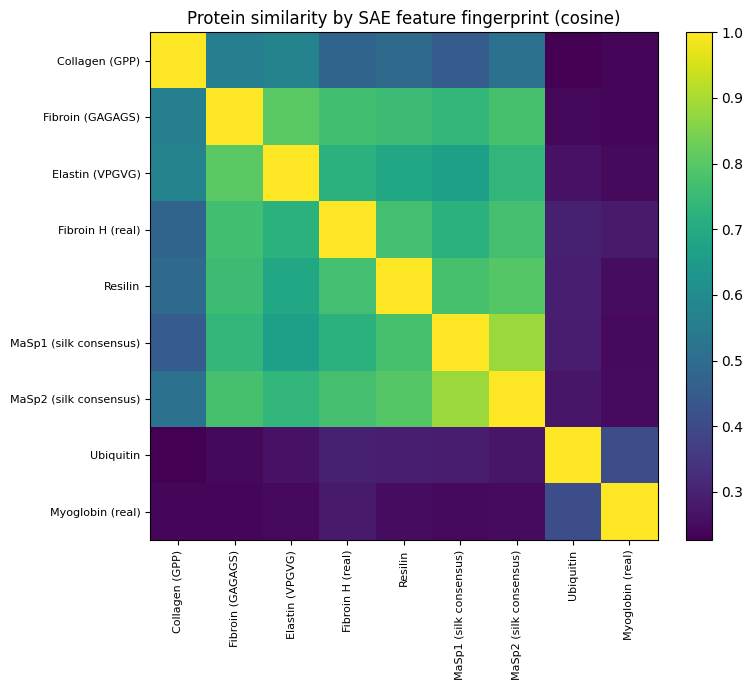

In [11]:
# fingerprints (max activation per feature), L2-normalized
fp = np.stack([FEATS[n].max(0) for n in names])          # (n_proteins, 16384)
fpn = fp / (np.linalg.norm(fp, axis=1, keepdims=True) + 1e-9)
sim = fpn @ fpn.T

from scipy.cluster.hierarchy import linkage, leaves_list
Z = linkage(fpn, method="average", metric="cosine")
order = leaves_list(Z)

fig, ax = plt.subplots(figsize=(8.5, 7))
im = ax.imshow(sim[np.ix_(order, order)], cmap="viridis")
ax.set_xticks(range(len(names))); ax.set_xticklabels([names[i] for i in order], rotation=90, fontsize=8)
ax.set_yticks(range(len(names))); ax.set_yticklabels([names[i] for i in order], fontsize=8)
ax.set_title("Protein similarity by SAE feature fingerprint (cosine)")
fig.colorbar(im, fraction=0.046, pad=0.04)
plt.tight_layout(); savefig(fig, "D_fingerprint_similarity"); plt.show()

In [12]:
# Which features are SHARED across all proteins vs UNIQUE to one?
present = np.stack([(FEATS[n].max(0) > 1.0) for n in names])     # (n_proteins, 16384) boolean
ubiquity = present.sum(0)                                        # in how many proteins is it strong?
shared = np.where(ubiquity == len(names))[0]
unique_to = {n: np.where(present[i] & (ubiquity == 1))[0] for i, n in enumerate(names)}

print(f"features strong in ALL {len(names)} proteins (generic): {len(shared)}")
for fid in shared[:3]:
    print(f"    f{int(fid)}: {label_of(int(fid))}")
print("\nrepresentative UNIQUE features per protein:")
for n in names:
    u = unique_to[n]
    if len(u):
        fid = int(u[np.argmax(fp[names.index(n), u])])           # its strongest unique feature
        print(f"  {n:26} f{fid:5d}: {label_of(fid)}")

features strong in ALL 9 proteins (generic): 22
    f1363: Generic feature, unknown meaning  [None]
    f1803: Unknown generic feature  [None]
    f2692: Compositionally biased disordered regions  [Compositional bias]

representative UNIQUE features per protein:
  MaSp1 (silk consensus)     f11810: Disordered regulatory tails in TFs  [Disorder]
  MaSp2 (silk consensus)     f 6881: Q/H-rich disordered TADs  [Compositional bias]
  Fibroin (GAGAGS)           f 3579: Cleavage P1′ and N-termini  [Post-translational modification]
  Collagen (GPP)             f 5402: Collagen Gly–X–Y repeat detector  [Repeat]
  Elastin (VPGVG)            f 9809: Solenoid repeat register detector  [Repeat]
  Resilin                    f14503: Structured aromatic hotspot detector  [Ligand-binding site]
  Ubiquitin                  f 3995: Ubiquitin-like domain modules  [Domain]
  Fibroin H (real)           f 7696: Sec/X and low-complexity detector  [Disorder]
  Myoglobin (real)           f 4055: Heme-based O2/N

**Read it as:** *shared* features are generic (length, common residues), while *unique* features
are candidate **family signatures** — e.g. a poly-Ala/β-crystal feature for silk, a `GXY`/collagen
feature for collagen. The clustering should group the silks together and separate the globular
controls.

## 9 · Interactive: explore any protein × feature

Pick a protein and one of its top features to see where it fires and what it (allegedly) means.
*(Needs a live kernel.)*

In [13]:
try:
    import ipywidgets as widgets

    def explore(protein, rank_by, rank):
        F = FEATS[protein]; seq = PROTEINS[protein]
        score = F.max(0) if rank_by == "max activation" else (F > 0).sum(0)
        fid = int(np.argsort(score)[::-1][rank])
        d = feature_info(fid)
        fig, ax = plt.subplots(figsize=(13, 2.6))
        ax.bar(np.arange(len(seq)), F[:, fid], width=1.0, color="darkorange")
        ax.set_title(f"{protein} | feature {fid} (rank {rank} by {rank_by})\n"
                     f"{d.get('label')}  [{d.get('category')}]", fontsize=10, loc="left")
        ax.set_xlabel("residue position"); ax.set_ylabel("activation")
        plt.tight_layout(); plt.show()
        print("summary:", d.get("summary"))

    widgets.interact(
        explore,
        protein=widgets.Dropdown(options=list(PROTEINS), value=silk),
        rank_by=widgets.Dropdown(options=["max activation", "prevalence"], value="max activation"),
        rank=widgets.IntSlider(min=0, max=9, value=0),
    )
except Exception as e:
    print("Interactive view needs a live Jupyter kernel. (", e, ")")

interactive(children=(Dropdown(description='protein', index=1, options=('MaSp1 (silk consensus)', 'MaSp2 (silk…

## 10 · Interpreting & caveats

**Activation shapes** (from the tutorial, applied to biomaterials):
- *Sharp peaks* → short motifs (poly-Ala crystallite edges, `GPGXX` turns, `GXY` register).
- *Broad activation* → secondary-structure runs, domains, low-complexity/repeat character.
- *Global activation* → fold class, ordered-vs-disordered, family/taxonomic signal.

**Caveats (important for class):**
- SAE features are *interpretability hypotheses*, not validated annotations; descriptions are
  auto-generated and can be wrong, especially for rare biology.
- Rankings depend on the aggregation (max vs. prevalence) and we used **no TF-IDF normalization**
  (the Forge API offers it); common features may dominate.
- We used **one SAE (layer 60, 16,384, k=64)**. Other layers/codebook sizes expose different concepts.

### Exercises
1. Find a feature that fires **only on poly-Ala** (mask/inspect MaSp1) and check its description.
2. Re-run §7 on collagen vs. ubiquitin — does the painted feature localize to a structural element?
3. Replace the SAE with `…codebook65536` and see whether features get more specific.
4. Build a feature-fingerprint **nearest-neighbor** search: given a new sequence, find the panel
   protein with the most similar fingerprint.

### References
- Biohub cookbook: *Understanding Proteins with SAE Features* (tutorial this is adapted from).
- ESMC SAE model cards: `biohub/ESMC-6B-sae-...`; feature descriptions via the ESM Atlas.